In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
a1cf_df = pd.read_csv('/home/sreeramp/cancer_dependency_project/sreeram/matrix_factorisation/A1CF_self/A1CF_self_test_results.csv', header = 0, index_col = 0)
a1cf_df.head()

,actual_dep_A1CF,actual_IC50,pred_IC50_A1CF,pred_dep_A1CF,benefit_score_A1CF
42MGBA,0.044468,7.08382,0.343475,0.033910,-0.055579
647V,0.095791,10.39050,0.426728,-0.034772,-0.130735
697,0.048517,1.95427,2.379079,-0.011519,-1.084985
786O,0.036812,7.13175,-0.230633,0.020073,0.221565
A2058,0.104388,6.32569,2.789688,0.030487,-1.267318


In [3]:
from scipy.stats import mannwhitneyu, pearsonr, spearmanr

In [ ]:
def compute_stats(x, y, alternative = 'two-sided'):
    U, p = mannwhitneyu(x, y, alternative=alternative)
    n1, n2 = len(x), len(y)
    rbc = 1 - (2 * U) / (n1 * n2)
    return U, p, rbc

In [9]:
# benefit score quartile boxplots
# ---- 1. Create quartiles ----
a1cf_df['quartile'] = pd.qcut(
    a1cf_df['benefit_score_A1CF'],
    q=4,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
)

order = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']

# ---- 2. Color palette ----
palette = ['#9ecae1', "#b8adad", '#f4a582', '#ca0020']  # blue → grey → orange → red

# ---- 3. Plot function ----
def make_panel(df, y, title_label):
    ax = sns.boxplot(
        data=df,
        x='quartile',
        y=y,
        order=order,
        palette=palette,
        width=0.6,
        fliersize=0
    )

    sns.stripplot(
        data=df,
        x='quartile',
        y=y,
        order=order,
        color='black',
        alpha=0.4,
        jitter=0.2,
        size=3,
        ax=ax
    )

    # # ---- stats annotations ----
    # pairs = [
    #     ('Q1 (Low)', 'Q2'),
    #     ('Q2', 'Q3'),
    #     ('Q3', 'Q4 (High)'),
    #     ('Q1 (Low)', 'Q4 (High)')
    # ]

    # annotator = Annotator(
    #     ax,
    #     pairs,
    #     data=df,
    #     x='quartile',
    #     y=y,
    #     order=order
    # )

    # annotator.configure(
    #     test='Mann-Whitney',
    #     text_format='star',
    #     loc='inside',
    #     verbose=0
    # )

    # annotator.apply_and_annotate()

    # ---- styling ----
    ax.set_xlabel('')
    ax.set_title(title_label, fontsize=12)
    sns.despine(ax=ax)
    plt.show()

/tmp/ipykernel_2924548/3646199643.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


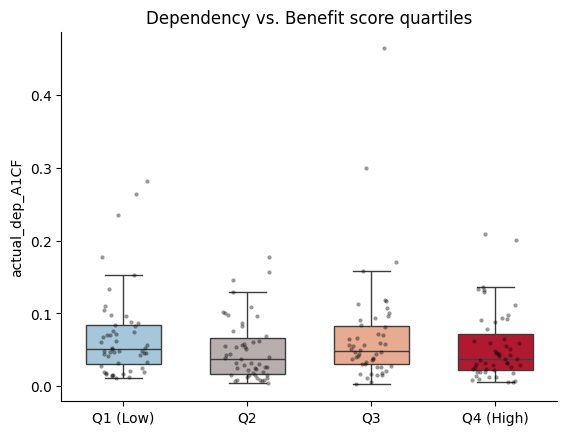

In [10]:
make_panel(df=a1cf_df, y = 'actual_dep_A1CF', title_label = 'Dependency vs. Benefit score quartiles')

/tmp/ipykernel_2924548/3646199643.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


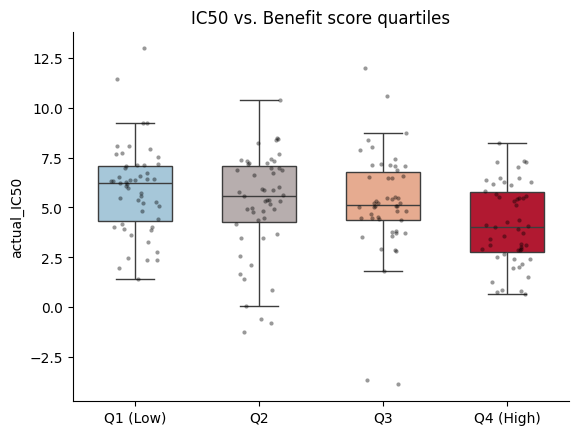

In [12]:
make_panel(df=a1cf_df, y = 'actual_IC50', title_label = 'IC50 vs. Benefit score quartiles')

In [13]:
import pickle

In [14]:
with open('/home/sreeramp/cancer_dependency_project/sreeram/matrix_factorisation/A1CF_self/A1CF_self_intermediate_objects.pkl', 'rb') as f:
  a1cf_data = pickle.load(f)

In [16]:
a1cf_data.keys()

dict_keys(['W_A1CF', 'hd_A1CF', 'hk_A1CF', 'train_cell_lines', 'test_cell_lines'])

In [17]:
a1cf_df['cell_line'] = a1cf_df.index

In [18]:
a1cf_df.head()

,actual_dep_A1CF,actual_IC50,pred_IC50_A1CF,pred_dep_A1CF,benefit_score_A1CF,quartile,cell_line
42MGBA,0.044468,7.08382,0.343475,0.033910,-0.055579,Q3,42MGBA
647V,0.095791,10.39050,0.426728,-0.034772,-0.130735,Q2,647V
697,0.048517,1.95427,2.379079,-0.011519,-1.084985,Q1 (Low),697
786O,0.036812,7.13175,-0.230633,0.020073,0.221565,Q3,786O
A2058,0.104388,6.32569,2.789688,0.030487,-1.267318,Q1 (Low),A2058


In [22]:
train_df = a1cf_df.loc[a1cf_df['set'] == 'train']
test_df = a1cf_df.loc[a1cf_df['set'] == 'test']

<Axes: xlabel='actual_IC50', ylabel='pred_IC50_A1CF'>

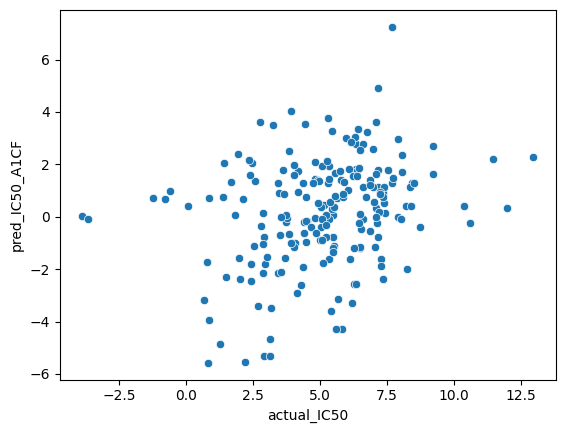

In [24]:
sns.scatterplot(data=test_df, y='pred_IC50_A1CF', x='actual_IC50')

<Axes: xlabel='actual_dep_A1CF', ylabel='pred_dep_A1CF'>

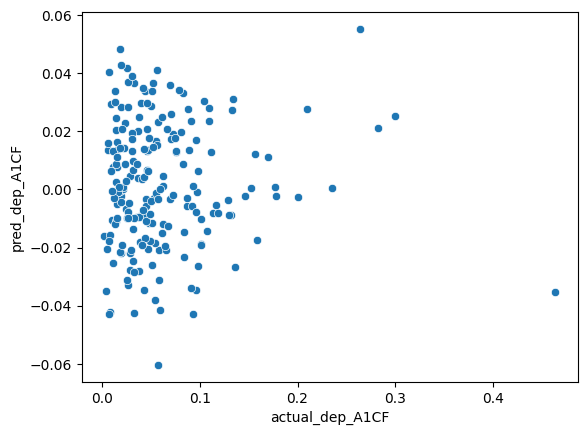

In [25]:
sns.scatterplot(data=test_df, y='pred_dep_A1CF', x='actual_dep_A1CF')